In [79]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

%matplotlib inline
pd.set_option('display.max_columns',None)

In [ ]:
# Defining a custom color palette
TEAL = "#0F4C5C" # Primary colour
TEAL_LIGHT = "#5A8A99"

ACCENT = "#C04000" # For highlights and / or forecasts
GREY = "#4A4A4A" # For actuals and / or neutral elements

# Custom color palette for multi-series plots
custom_palette = ["#0F4C5C",
                  "#C04000",
                  "#2E5A2E",
                  "#7B2D26",
                  "#3D5A80",
                  "#8B6F47",
                  "#5C4B51",
                  "#A4B494",
                  "#9B5DE5",
                  "#4A4A4A"] 
sns.set_theme(style = 'whitegrid', context = 'notebook',palette=custom_palette)

plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.prop_cycle'] = plt.cycler(color = custom_palette)

In [48]:
# Reading the data
df = pd.read_csv("../data/raw/city_domestic.csv")

In [49]:
#Shape of the dataset
df.shape

(63173, 10)

In [50]:
# First 5 rows of the dataset
df.head()

,Year,Month,City1,City2,PaxToCity2,PaxFromCity2,FreightToCity2,FreightFromCity2,MailToCity2,MailFromCity2
0,2021,12,ADAMPUR,AHMEDABAD,30.0,0.0,0.0,0.00,0.0,0.0
1,2018,5,ADAMPUR,DELHI,2258.0,2190.0,0.0,0.86,0.0,0.0
2,2018,6,ADAMPUR,DELHI,1984.0,1981.0,0.0,4.33,0.0,0.0
3,2018,7,ADAMPUR,DELHI,2333.0,2205.0,0.0,1.93,0.0,0.0
4,2018,8,ADAMPUR,DELHI,2146.0,1981.0,0.0,0.48,0.0,0.0


In [51]:
# Datatypes in the dataset
df.dtypes

Year                  int64
Month                 int64
City1                object
City2                object
PaxToCity2          float64
PaxFromCity2        float64
FreightToCity2      float64
FreightFromCity2    float64
MailToCity2         float64
MailFromCity2       float64
dtype: object

In [52]:
# Building a date column
df['date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))

In [53]:
df.head()

,Year,Month,City1,City2,PaxToCity2,PaxFromCity2,FreightToCity2,FreightFromCity2,MailToCity2,MailFromCity2,date
0,2021,12,ADAMPUR,AHMEDABAD,30.0,0.0,0.0,0.00,0.0,0.0,2021-12-01
1,2018,5,ADAMPUR,DELHI,2258.0,2190.0,0.0,0.86,0.0,0.0,2018-05-01
2,2018,6,ADAMPUR,DELHI,1984.0,1981.0,0.0,4.33,0.0,0.0,2018-06-01
3,2018,7,ADAMPUR,DELHI,2333.0,2205.0,0.0,1.93,0.0,0.0,2018-07-01
4,2018,8,ADAMPUR,DELHI,2146.0,1981.0,0.0,0.48,0.0,0.0,2018-08-01


In [54]:
# Aggregating the total number of passengers
df['Total_Pax'] = df['PaxToCity2'] + df['PaxFromCity2']

In [55]:
df.head()

,Year,Month,City1,City2,PaxToCity2,PaxFromCity2,FreightToCity2,FreightFromCity2,MailToCity2,MailFromCity2,date,Total_Pax
0,2021,12,ADAMPUR,AHMEDABAD,30.0,0.0,0.0,0.00,0.0,0.0,2021-12-01,30.0
1,2018,5,ADAMPUR,DELHI,2258.0,2190.0,0.0,0.86,0.0,0.0,2018-05-01,4448.0
2,2018,6,ADAMPUR,DELHI,1984.0,1981.0,0.0,4.33,0.0,0.0,2018-06-01,3965.0
3,2018,7,ADAMPUR,DELHI,2333.0,2205.0,0.0,1.93,0.0,0.0,2018-07-01,4538.0
4,2018,8,ADAMPUR,DELHI,2146.0,1981.0,0.0,0.48,0.0,0.0,2018-08-01,4127.0


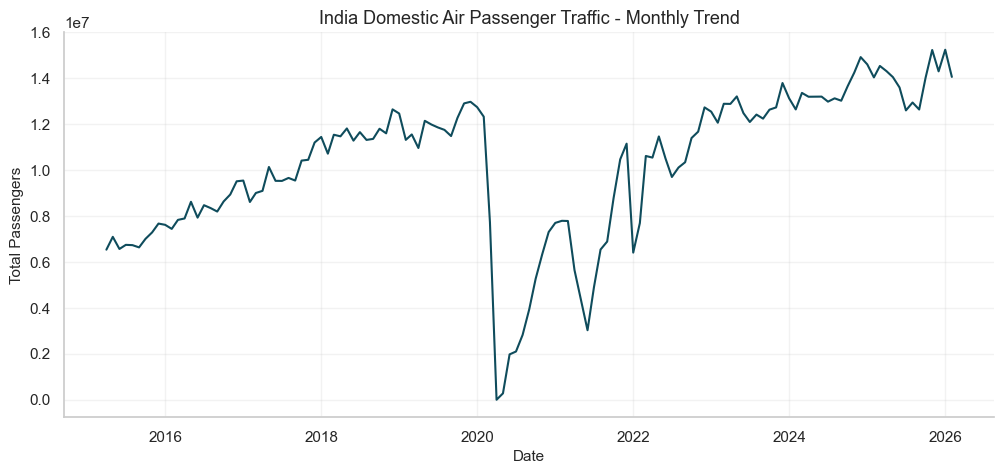

In [56]:
# Calculating and plotting the national monthly air traffic volume
national_monthly = df.groupby('date')['Total_Pax'].sum().reset_index()

plt.figure(figsize = (12,5))
plt.plot(national_monthly['date'],national_monthly['Total_Pax'])
plt.title('India Domestic Air Passenger Traffic - Monthly Trend')
plt.xlabel('Date')
plt.ylabel('Total Passengers')
plt.grid(alpha = 0.25)
plt.show()


In [57]:
# Identifying top 10 airports by passenger volume
top10_airports = df.groupby('City1')['Total_Pax'].sum().nlargest(10).index.tolist()
top10_airports

['DELHI',
 'BENGALURU',
 'MUMBAI',
 'AHMEDABAD',
 'CHENNAI',
 'HYDERABAD',
 'KOLKATA',
 'BHUBANESWAR',
 'DABOLIM',
 'GUWAHATI']

In [58]:
# Monthly aggregation at airport levels
airport_monthly = df.groupby(['City1','date'])['Total_Pax'].sum().reset_index()
airport_monthly

,City1,date,Total_Pax
0,ADAMPUR,2018-05-01,4448.0
1,ADAMPUR,2018-06-01,3965.0
2,ADAMPUR,2018-07-01,4538.0
3,ADAMPUR,2018-08-01,4127.0
4,ADAMPUR,2018-09-01,4401.0
...,...,...,...
8660,VIJAYAWADA,2025-12-01,11053.0
8661,VIJAYAWADA,2026-01-01,9939.0
8662,VIJAYAWADA,2026-02-01,9976.0
8663,ZIRO,2022-11-01,38.0


In [59]:
# Filtering the monthly aggregates for the top 10 airports by traffic volume
airport_top10 = airport_monthly[airport_monthly['City1'].isin(top10_airports)]
airport_top10

,City1,date,Total_Pax
414,AHMEDABAD,2015-04-01,413524.0
415,AHMEDABAD,2015-05-01,459229.0
416,AHMEDABAD,2015-06-01,391942.0
417,AHMEDABAD,2015-07-01,387083.0
418,AHMEDABAD,2015-08-01,398389.0
...,...,...,...
7148,MUMBAI,2025-10-01,501977.0
7149,MUMBAI,2025-11-01,525508.0
7150,MUMBAI,2025-12-01,513609.0
7151,MUMBAI,2026-01-01,713465.0


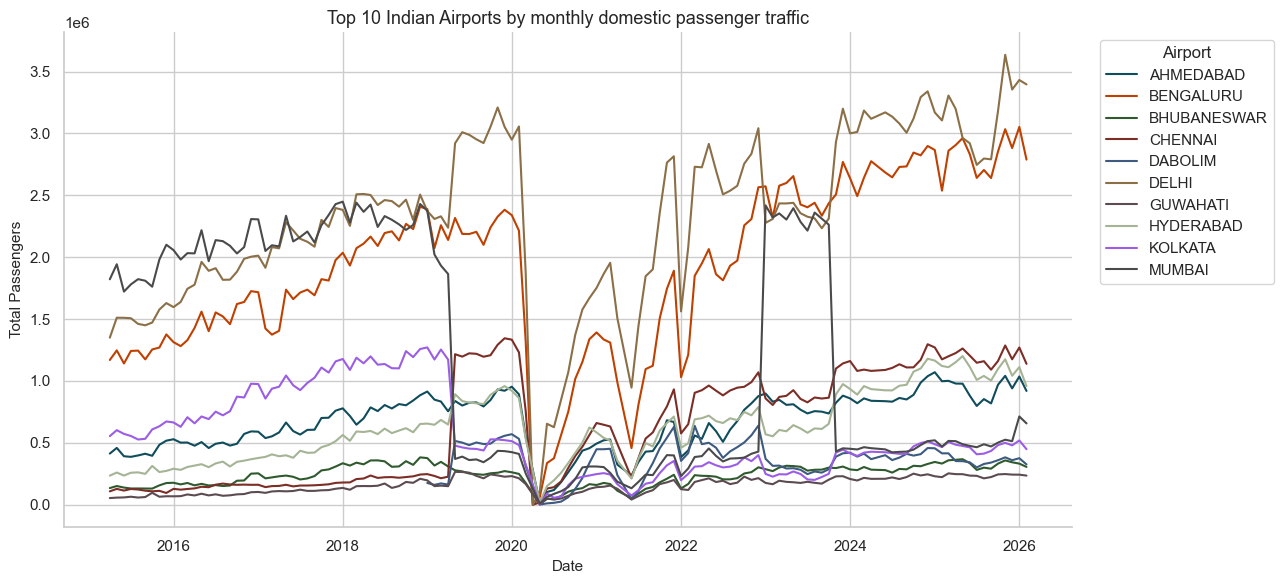

In [60]:
# Plotting the monthly traffic trends for the top 10 airports
plt.figure(figsize=(13,6))
sns.lineplot(data = airport_top10, x = 'date', y = 'Total_Pax', hue = 'City1',palette=custom_palette)
plt.title('Top 10 Indian Airports by monthly domestic passenger traffic')
plt.xlabel("Date")
plt.ylabel('Total Passengers')
plt.legend(title = 'Airport',loc = 'upper left',bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

/var/folders/nq/rpmm4zk552n5ksgcbp8hz7j80000gn/T/ipykernel_27173/3005300733.py:4: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.lineplot(data = mumbai_monthly, x = 'date', y = 'Total_Pax', hue = 'City1',palette=custom_palette)


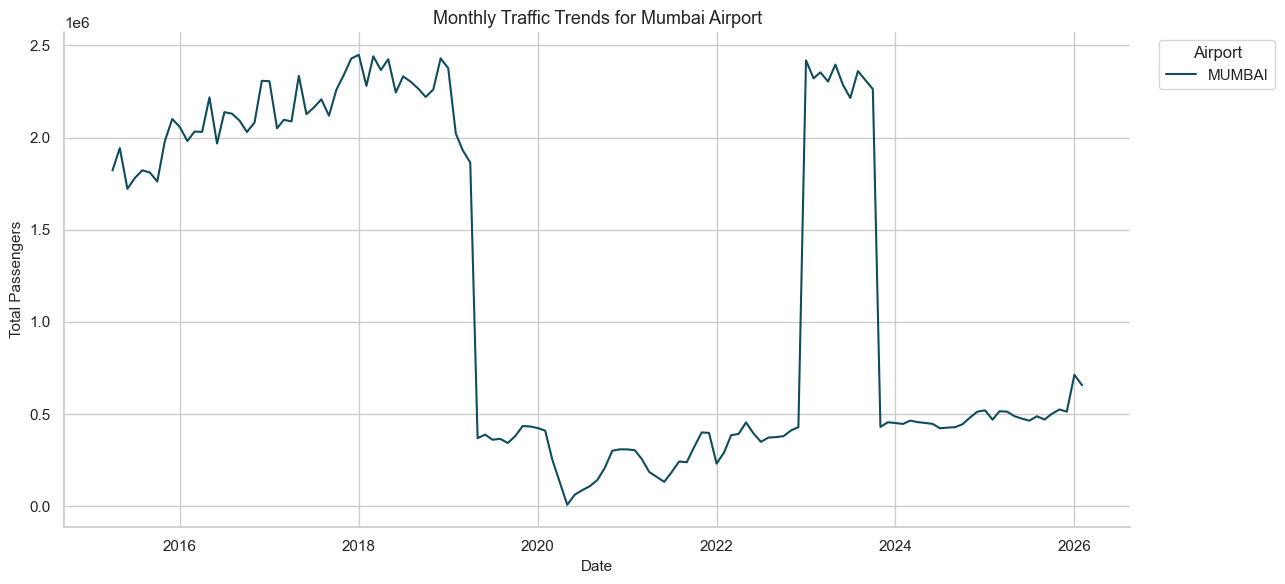

In [61]:
# Plotting the monthly traffic trends for Mumbai airport
mumbai_monthly = airport_monthly[airport_monthly['City1'] == 'MUMBAI'].sort_values('date')
plt.figure(figsize=(13,6))
sns.lineplot(data = mumbai_monthly, x = 'date', y = 'Total_Pax', hue = 'City1',palette=custom_palette)
plt.title('Monthly Traffic Trends for Mumbai Airport')
plt.xlabel("Date")
plt.ylabel('Total Passengers')
plt.legend(title = 'Airport',loc = 'upper left',bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

Mumbai's traffic trend showed two anomalies - two significant drops in 2019 and in 2023.

In [62]:
# Exploring the anomalies in Mumbai data
mumbai = airport_monthly[airport_monthly['City1'] == 'MUMBAI'].sort_values('date')
print("Mumbai months with zero or near-zero traffic:")
print(mumbai[mumbai['Total_Pax'] <= 100000][['date','Total_Pax']])

Mumbai months with zero or near-zero traffic:
           date  Total_Pax
7085 2020-05-01     8751.0
7086 2020-06-01    63569.0
7087 2020-07-01    87674.0


When I looked at the data for months where the data dropped below 100000, there were only three instances and none of these matched the anomalies noted in the previous chart.

In [63]:
# Check unique values that contain "MUM" or "BOM"
print("City1 values matching 'MUM' or 'BOM':")
print([c for c in df['City1'].unique() if 'MUM' in c.upper() or 'BOM' in c.upper()])

print("\nCity2 values matching 'MUM' or 'BOM':")
print([c for c in df['City2'].unique() if 'MUM' in c.upper() or 'BOM' in c.upper()])

# Look at Mumbai data around the suspect periods
print("\nMumbai monthly traffic, mid-2019 to early 2020:")
mumbai_2019 = airport_monthly[(airport_monthly['City1'] == 'MUMBAI') & 
                                (airport_monthly['date'] >= '2019-01-01') & 
                                (airport_monthly['date'] <= '2020-06-01')]
print(mumbai_2019.to_string())

print("\nMumbai monthly traffic, mid-2022 to mid-2024:")
mumbai_2023 = airport_monthly[(airport_monthly['City1'] == 'MUMBAI') & 
                                (airport_monthly['date'] >= '2022-06-01') & 
                                (airport_monthly['date'] <= '2024-06-01')]
print(mumbai_2023.to_string())

City1 values matching 'MUM' or 'BOM':
['MUMBAI']

City2 values matching 'MUM' or 'BOM':
['MUMBAI']

Mumbai monthly traffic, mid-2019 to early 2020:
       City1       date  Total_Pax
7070  MUMBAI 2019-01-01  2376219.0
7071  MUMBAI 2019-02-01  2021992.0
7072  MUMBAI 2019-03-01  1932044.0
7073  MUMBAI 2019-04-01  1864326.0
7074  MUMBAI 2019-05-01   369994.0
7075  MUMBAI 2019-06-01   388939.0
7076  MUMBAI 2019-07-01   361267.0
7077  MUMBAI 2019-08-01   366258.0
7078  MUMBAI 2019-09-01   343671.0
7079  MUMBAI 2019-10-01   379874.0
7080  MUMBAI 2019-11-01   435603.0
7081  MUMBAI 2019-12-01   433267.0
7082  MUMBAI 2020-01-01   424897.0
7083  MUMBAI 2020-02-01   410525.0
7084  MUMBAI 2020-03-01   253569.0
7085  MUMBAI 2020-05-01     8751.0
7086  MUMBAI 2020-06-01    63569.0

Mumbai monthly traffic, mid-2022 to mid-2024:
       City1       date  Total_Pax
7109  MUMBAI 2022-06-01   394923.0
7110  MUMBAI 2022-07-01   349872.0
7111  MUMBAI 2022-08-01   373318.0
7112  MUMBAI 2022-09-01   375643.0


To explore and figure out what happened in the first drop around 2019, I filtered the data from mid-2019 to early 2020. The traffic volume dropped from 1864326 in April 2019 to 369994 in May 2019 and continued to be in this range till the outbreak of COVID 19 in March 2020.

In [64]:
print("\nMumbai monthly traffic, mid-2022 to mid-2024:")
mumbai_2023 = airport_monthly[(airport_monthly['City1'] == 'MUMBAI') & 
                                (airport_monthly['date'] >= '2022-06-01') & 
                                (airport_monthly['date'] <= '2024-06-01')]
print(mumbai_2023.to_string())


Mumbai monthly traffic, mid-2022 to mid-2024:
       City1       date  Total_Pax
7109  MUMBAI 2022-06-01   394923.0
7110  MUMBAI 2022-07-01   349872.0
7111  MUMBAI 2022-08-01   373318.0
7112  MUMBAI 2022-09-01   375643.0
7113  MUMBAI 2022-10-01   380553.0
7114  MUMBAI 2022-11-01   412007.0
7115  MUMBAI 2022-12-01   429482.0
7116  MUMBAI 2023-01-01  2418707.0
7117  MUMBAI 2023-02-01  2321324.0
7118  MUMBAI 2023-03-01  2353681.0
7119  MUMBAI 2023-04-01  2303933.0
7120  MUMBAI 2023-05-01  2395956.0
7121  MUMBAI 2023-06-01  2285670.0
7122  MUMBAI 2023-07-01  2214831.0
7123  MUMBAI 2023-08-01  2360553.0
7124  MUMBAI 2023-09-01  2311115.0
7125  MUMBAI 2023-10-01  2262882.0
7126  MUMBAI 2023-11-01   430865.0
7127  MUMBAI 2023-12-01   455957.0
7128  MUMBAI 2024-01-01   452192.0
7129  MUMBAI 2024-02-01   446906.0
7130  MUMBAI 2024-03-01   465114.0
7131  MUMBAI 2024-04-01   457044.0
7132  MUMBAI 2024-06-01   447380.0


I did a similar exercise to understand what happened in 2023, and the filtered data showed a drop in December 2022 followed by a spike in January 2023 and another drop in November 2023. This was clearly not an one-off incident.

In [65]:
# Check national monthly totals at the same time points
nat = df.groupby('date')['Total_Pax'].sum().reset_index()
print("National monthly traffic - sanity check periods:")
print(nat[(nat['date'] >= '2023-08-01') & (nat['date'] <= '2024-06-01')].to_string())

National monthly traffic - sanity check periods:
          date   Total_Pax
99  2023-08-01  12422673.0
100 2023-09-01  12246549.0
101 2023-10-01  12636742.0
102 2023-11-01  12735394.0
103 2023-12-01  13797352.0
104 2024-01-01  13131603.0
105 2024-02-01  12647306.0
106 2024-03-01  13367468.0
107 2024-04-01  13200048.0
108 2024-06-01  13205828.0


When I checked the national totals during the same period, the monthly totals remained stable in the same range. This indicates that the passenger volume didn't drop as such and it is most probably a Mumbai specific data tagging issue.

In [66]:
# Check Delhi, Bengaluru, Chennai for similar discontinuities
for city in ['DELHI', 'BENGALURU', 'CHENNAI', 'HYDERABAD', 'KOLKATA']:
    city_data = airport_monthly[airport_monthly['City1'] == city].sort_values('date')
    # Compute month-over-month % change
    city_data = city_data.copy()
    city_data['pct_change'] = city_data['Total_Pax'].pct_change() * 100
    # Flag months with >50% drop
    big_drops = city_data[city_data['pct_change'] < -50]
    print(f"\n{city} — months with >50% MoM drop:")
    print(big_drops[['date', 'Total_Pax', 'pct_change']].to_string())


DELHI — months with >50% MoM drop:
           date  Total_Pax  pct_change
2936 2020-04-01        0.0      -100.0

BENGALURU — months with >50% MoM drop:
           date  Total_Pax  pct_change
1360 2020-04-01        0.0 -100.000000
1373 2021-06-01   457480.0  -53.735456

CHENNAI — months with >50% MoM drop:
           date  Total_Pax  pct_change
2341 2020-04-01        0.0 -100.000000
2354 2021-06-01   216475.0  -55.924332

HYDERABAD — months with >50% MoM drop:
           date  Total_Pax  pct_change
4264 2020-05-01    15583.0  -97.076799

KOLKATA — months with >50% MoM drop:
           date  Total_Pax  pct_change
6149 2019-05-01   477469.0  -59.284503
6160 2020-05-01     2137.0  -99.344786
6172 2021-06-01    74313.0  -55.236368


To ensure that it's a Mumbai specific anomaly, I ran similar diagnostics for the other major airports as well. As expected they showed a significant drop during the COVID pandemic period alone.

I've decided to proceed with all airports including Mumbai. The hierarchical reconciliation step (Minimum Trace Method) will help correct the airport-level forecasts when they conflict with route-level patterns. However, this needs to be addressed if the forecasts are distorted during evaluation.

In [67]:
# Creating a readable label for routes
df['route'] = df['City1'] + " - " + df['City2']

# Top 10 routes by passenger volume
top_10_routes = df.groupby('route')['Total_Pax'].sum().nlargest(10).reset_index()
print("Top 10 routes by total passenger volume:")
print(top_10_routes.to_string(index=False))

Top 10 routes by total passenger volume:
                route  Total_Pax
    BENGALURU - DELHI 41800685.0
   BENGALURU - MUMBAI 35410657.0
       MUMBAI - DELHI 32727485.0
       DELHI - MUMBAI 29999612.0
    DELHI - HYDERABAD 26940468.0
         DELHI - PUNE 24793903.0
    AHMEDABAD - DELHI 20861016.0
     DELHI - SRINAGAR 19523171.0
   AHMEDABAD - MUMBAI 18937829.0
BENGALURU - HYDERABAD 18887569.0


/var/folders/nq/rpmm4zk552n5ksgcbp8hz7j80000gn/T/ipykernel_27173/1607582413.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_10_routes, x = 'Total_Pax', y = 'route',palette=custom_palette, orient='h')


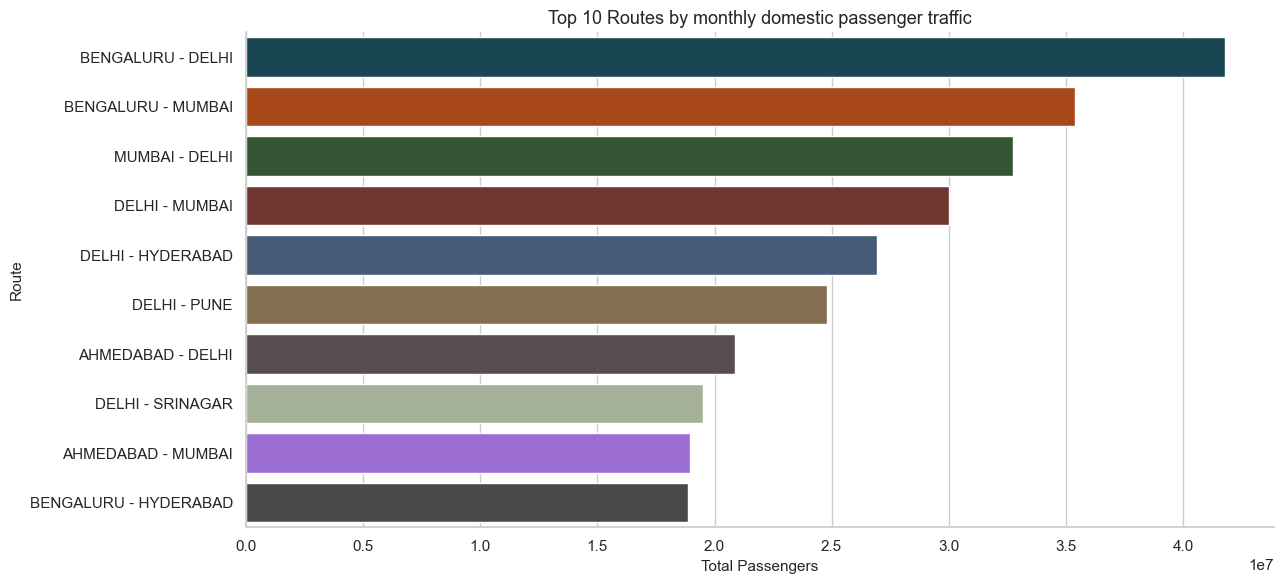

In [68]:
# Plotting the monthly traffic trends for the top 10 routes
plt.figure(figsize=(13,6))
sns.barplot(data = top_10_routes, x = 'Total_Pax', y = 'route',palette=custom_palette, orient='h')
plt.title('Top 10 Routes by monthly domestic passenger traffic')
plt.ylabel("Route")
plt.xlabel('Total Passengers')
plt.tight_layout()
plt.show()

In [69]:
total_pax = df['Total_Pax'].sum()
route_totals = df.groupby('route')['Total_Pax'].sum().sort_values(ascending=False)

print(f"Total national passengers (cumulative all years): {total_pax/1e6:.1f}M")
print(f"\nTop 50 routes capture: {route_totals.head(50).sum()/total_pax*100:.1f}%")
print(f"Top 100 routes capture: {route_totals.head(100).sum()/total_pax*100:.1f}%")
print(f"Top 200 routes capture: {route_totals.head(200).sum()/total_pax*100:.1f}%")
print(f"\nTotal unique routes: {len(route_totals)}")

Total national passengers (cumulative all years): 1323.6M

Top 50 routes capture: 49.7%
Top 100 routes capture: 67.5%
Top 200 routes capture: 85.2%

Total unique routes: 1855


In [73]:
#STL Decomposition for national air traffic
national_series = national_monthly.set_index('date')['Total_Pax']

# Resample to monthly start frequency, filling missing months 
national_series = national_series.asfreq('MS')

# Check the resampled data
print("Missing values after resampling:")
print(national_series[national_series.isna()])

# Inerpolate the missing month
national_series = national_series.interpolate(method='linear')

print("May 2024 after interpolation: ",national_series.loc['2024-05-01'])

Missing values after resampling:
date
2021-05-01   NaN
2024-05-01   NaN
Name: Total_Pax, dtype: float64
May 2024 after interpolation:  13202938.0


In [74]:
print("Traffic around May 2021:")
print(national_series.loc['2021-03-01':'2021-07-01'])

Traffic around May 2021:
date
2021-03-01    7787310.0
2021-04-01    5647434.0
2021-05-01    4338038.5
2021-06-01    3028643.0
2021-07-01    4897664.0
Freq: MS, Name: Total_Pax, dtype: float64


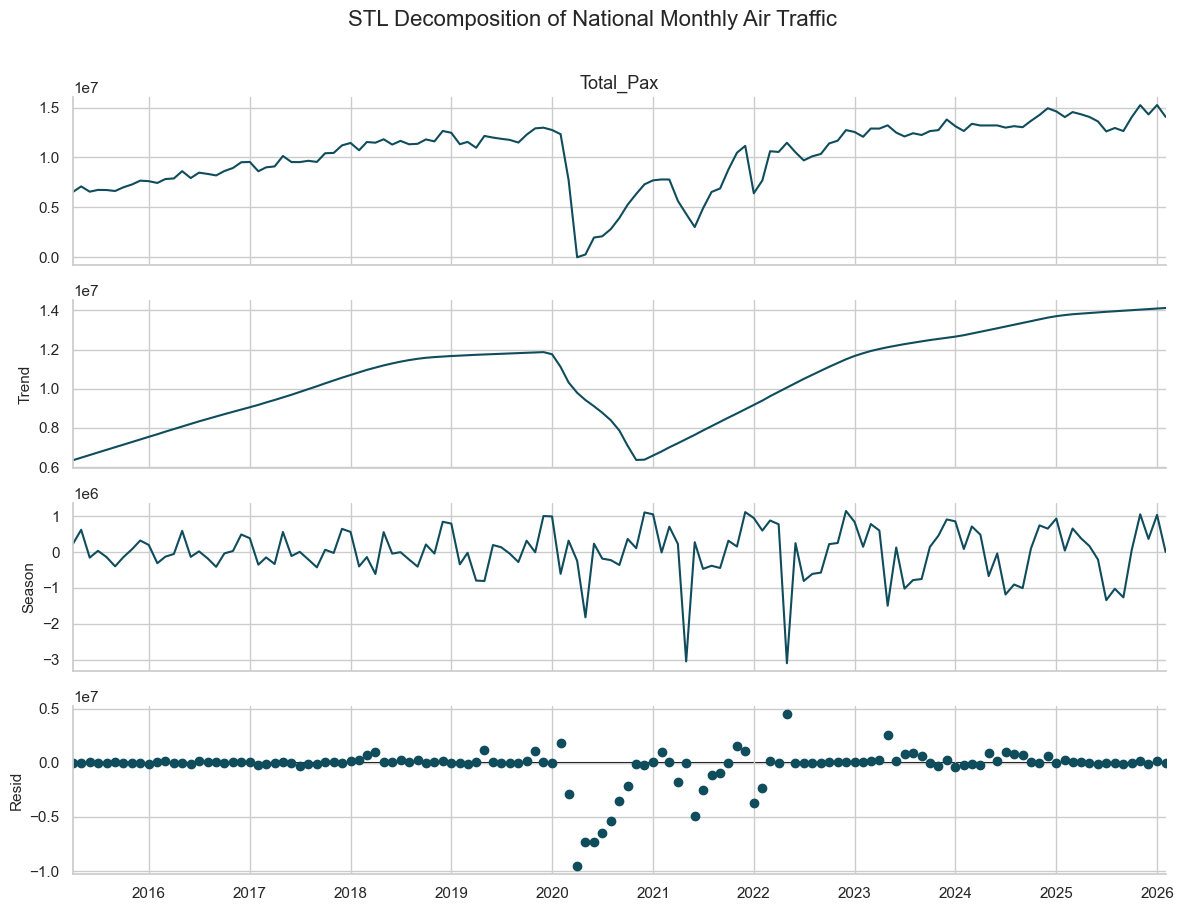

In [75]:
# Decomposing the time series
stl = STL(national_series, period = 12, robust = True)
result = stl.fit()

# Plot the decomposition
fig = result.plot()
fig.set_size_inches(12, 9)
plt.suptitle('STL Decomposition of National Monthly Air Traffic', fontsize=16, y = 1.01)
plt.tight_layout()
plt.show()

The STL decomposition reveals three distinct phases of Indian aviation industry's recent history - pre-COVID growth, the disruption caused by the pandemic and the post-COVID recovery and return to normalcy.

*Trend* panel clearly shows a strong growth trajectory from 2015 to 2019, with the growth almost slowing down before the COVID induced drop in 2020. This is followed by a recovery trajectory from 2021 onwards and a continued growth from 2023 till date.

*Seasonality* pattern is uneven. Pre-COVID, the pattern is stable. During the COVID period, there are steep drops and the pattern attains stability post 2023. The seasonal pattern is disrupted by COVID and the pattern pre-COVID and post-COVID are significantly different. This also indicates that pre-COVID seasonal patterns may not be a reliable factor for forecasting the demands post the pandemic. 

*Residuals* are mostly zero except for the COVID period. The COVID effect which is not fully absorbed or explained by the seasonal component of the decomposition is visible here. If I have to use the full data without intervention variables for forecasting, these residuals might create an issue.

The strong trend component is in favour of ARIMA's differencing-based approach. The unstable seasonality components indicate multiplicative ETS variants may outperform additive ones. The residuals during COVID period flag a risk for forecast evaluation. Even if the base forecasts show distortion, the hierarchical reconciliation step should at least to some extent, fix it by ensuring cross-level coherence. 

In [76]:
# Month-of-Year Seasonality Chart

# Month-of-Year Aggregations
seasonal_data = national_monthly.copy()
seasonal_data['month'] = seasonal_data['date'].dt.month
seasonal_data['year'] = seasonal_data['date'].dt.year

# Calculating the average over years for each month
all_years_average = seasonal_data.groupby('month')['Total_Pax'].mean().reset_index()
all_years_average['period'] = 'All Years (2015-2026)'

# Calculating Pre-COVID average (2015 to 2019)
pre_covid_average = seasonal_data[seasonal_data['year'] < 2020].groupby('month')['Total_Pax'].mean().reset_index()
pre_covid_average['period'] = 'Pre-COVID (2015-2019)'

# Calculating Post-COVID average (2023 to 2026)
post_recovery_average = seasonal_data[seasonal_data['year'] >= 2023].groupby('month')['Total_Pax'].mean().reset_index()
post_recovery_average['period'] = 'Post-Recovery (2023-2026)'

# Combine all three for plotting
combined_seasonality = pd.concat([all_years_average, pre_covid_average, post_recovery_average])

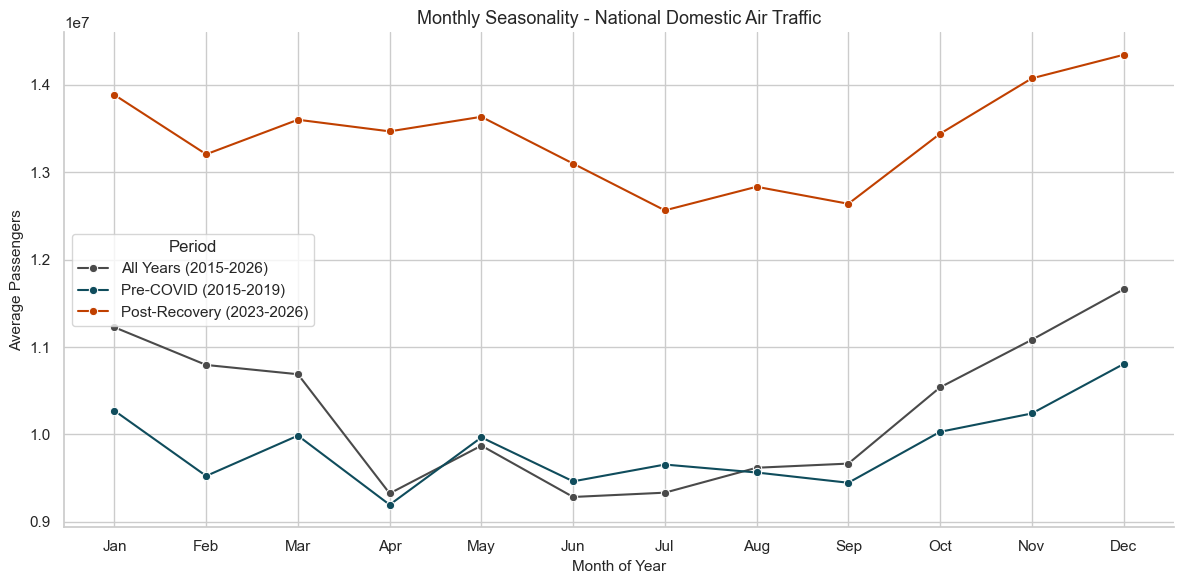

In [78]:
# Plotting the monthl-of-year seasonality charts
plt.figure(figsize=(12,6))
sns.lineplot(data = combined_seasonality, x = 'month', y = 'Total_Pax', hue = 'period', marker='o', palette=[GREY,TEAL, ACCENT],markers= 'o')
plt.title('Monthly Seasonality - National Domestic Air Traffic')
plt.xlabel('Month of Year')
plt.ylabel('Average Passengers')
plt.xticks(range(1,13),['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title = 'Period')
plt.tight_layout()
plt.show()



Pre-COVID and Post-Recovery lines reveal that the seasonality of air traffic volume survived the pandemic. The pattern shows a January peak, an April to September trough (monsoon months are the weakest during this period) and a strong rally from October to December, coinciding with the wedding and holiday seasons of the year. The patterns more-or-less remain the same while the volume has shown a 35-40% lift. The stability validates my decision to use the full dataset with seasonal models rather than relying just on the post-recovery period. Since the seasonality is real and significant, multiplicative ETS is the right fit. The all years average line sits in between the pre and post pandemic lines, clearly signalling the dampening effect of the pandemic.    

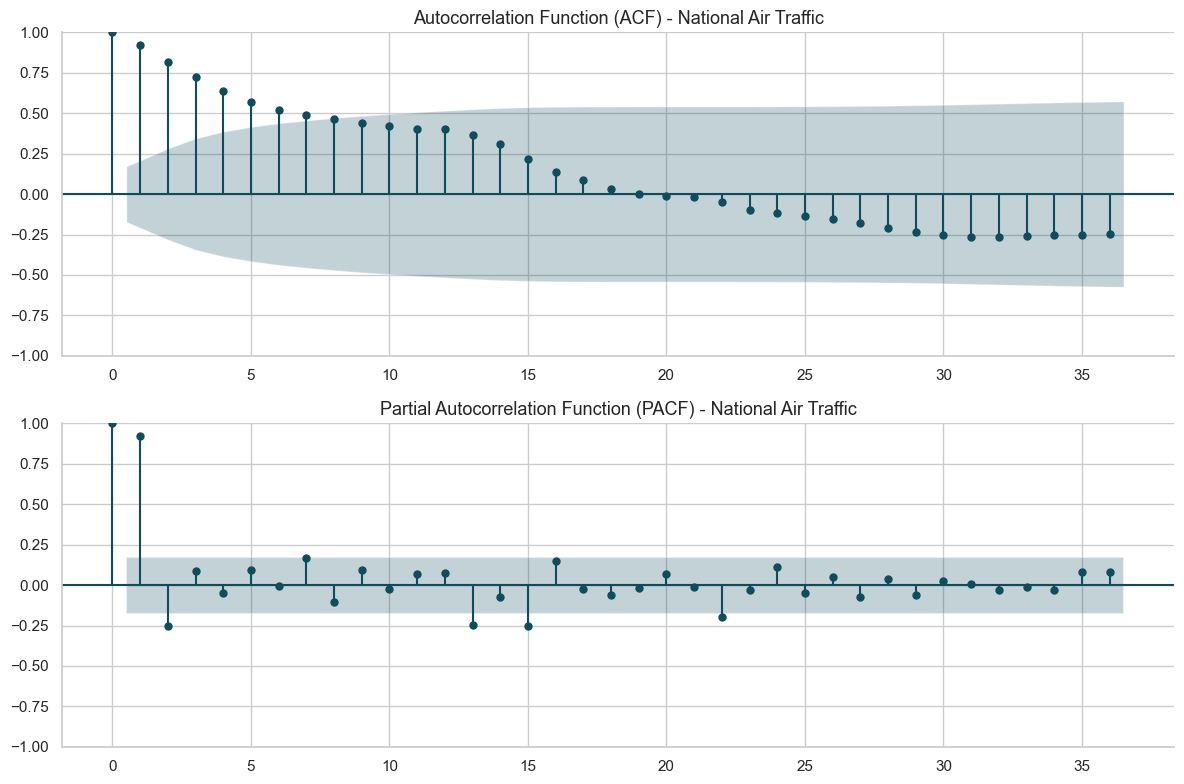

In [80]:
# ACF and PACF Plots
fig, axes = plt.subplots(2,1, figsize=(12,8))

# ACF Plot
plot_acf(national_series, lags=36, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) - National Air Traffic')

# PACF Plot
plot_pacf(national_series, lags=36, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) - National Air Traffic')

plt.tight_layout()
plt.show()


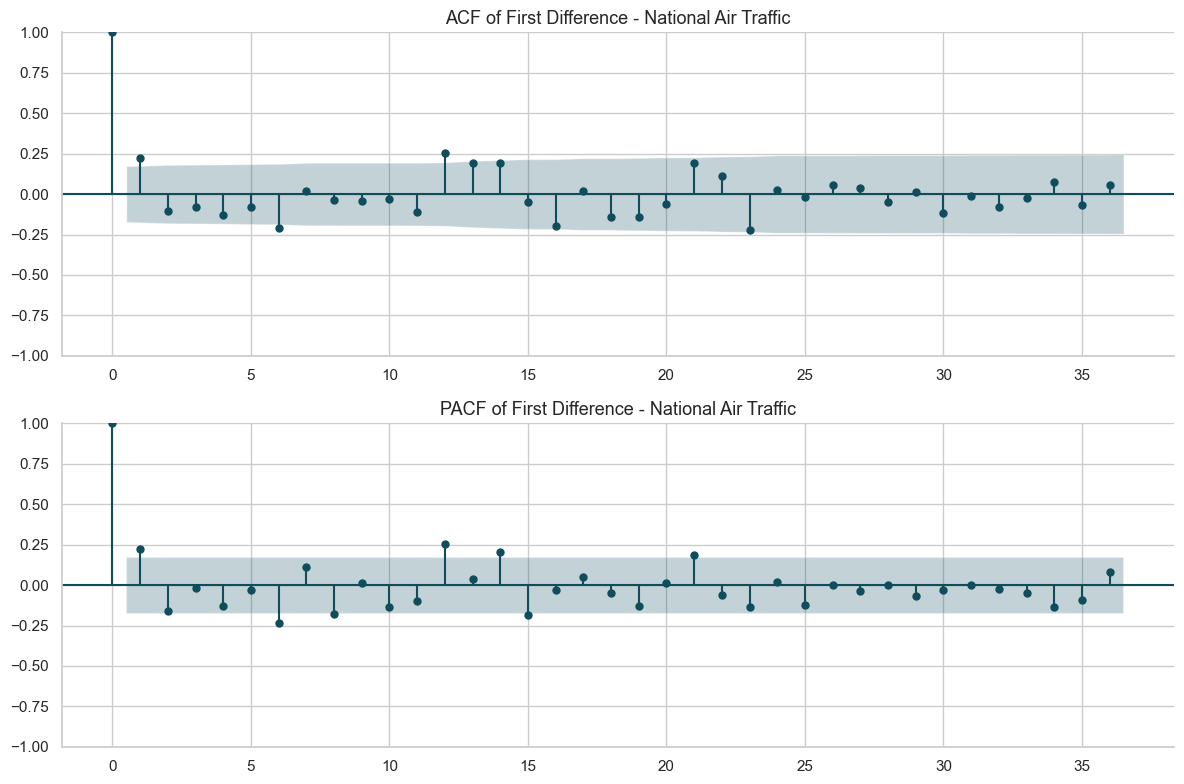

In [81]:
# First Difference ACF and PACF plots
national_difference = national_series.diff().dropna()

fig, axes = plt.subplots(2,1, figsize=(12,8))

plot_acf(national_difference, lags=36, ax=axes[0])
axes[0].set_title('ACF of First Difference - National Air Traffic')

plot_pacf(national_difference, lags=36, ax=axes[1])
axes[1].set_title('PACF of First Difference - National Air Traffic')

plt.tight_layout()
plt.show()

The original ACF/PACF charts indicate a slow ACF decay up to lag 18 confirming a trend. PACF spikes only at lag 1, suggesting strong autoregressive dependence on the preceding month alone. I tried removing the trend by doing a first difference and lag 12 still showed a spike, indicating annual seasonality. Anti-correlation at lag 6 once again confirms the peak-trough pattern observed earlier in the series. These observations support modelling using AutoARIMA with seasonal differencing. A low-order model is expected (lower numbers for the parameters of ARIMA - p, d and q).

## Modelling Decisions

Based on the exploratory data analysis above, I made the following decisions before proceeding to the modelling and forecasting sections.

**1. Route Directionality**
Each directional route (city1 to city 2) shall be treated as a separate series. This is how airlines and passengers think about flights (Flight ABC from City XYZ to City PQR). This also captures the asymmetric flows between two cities. For establishing the hierarchy, the airport level series is defined as the total outbound traffic from each origin airport. This keeps the hierarchy a strict tree (Total - Origin Airport - Directional Routes). Each level in this hierarchy is a clean aggregation of the level below and this is necessary for effective reconciliation. The project is trying to forecast directional outbound traffic, and since at the national level, total outbound traffic equals the total inbound traffic, there is no loss of data points in the analysis.

**2. COVID Handling**
I will be using the full data available from 2015 to 2026 for the modelling here. AutoARIMA and ETS are robust to one time shocks. This assumption will be revisited if the forecasts get distorted by COVID drops. Intervention variables are not considered at this point of time.

**3. Route Filter**
Top 200 directional routes by total passenger volume subject to data availability for minimum 60 months are filtered for modelling. This captures approx. 79% of the total volume while including Tier 2 and Tier 3 cities. The filter will also help exclude routes that are seasonal or sparsely used, which can distort the forecasts.

**4. Train and Test Splits**
Last 12 month data (March 2025 to February 2026) will be held out as the test set. This is the standard practice for monthly time series, as they cover one full seasonal cycle and leaves a good volume of data for training the model.

**5. Data Quality**
Data is not available for two months - May 2021 and May 2024. May 2021 coincides with India's second COVID wave (delta variant). This is likely a case of reporting disruption by DGCA. The latter instance, May 2024 seems to be a data quality issue at the source. I have applied linear interpolation to treat the missing values. Linear interpolation gives a passenger volume of 4.34M for May 2021, which is reasonable between April 2021's 5.65M and June 2021's 3.03M. Likewise, for May 2024, it is 13.20M, consistent with the preceding and succeeding months.

By these choices, I intend to balance analytical rigor with the realities of monthly aggregated public data, and align with conventions in the hierarchical forecasting literature (Hyndman & Athanasopoulos, Forecasting: Principles and Practice).